# **Spotify Customer Churn Analysis**

Analyzing user behavior to identify churn drivers and improve retention

# **1. Business Problem**

Customer Churn is a major issue for subscription based businesses because losing user directly affects revenue. This project analyzes Spotify customer behavior to identify patterns associated with churn. The goal is to better understand at-risk users and support data-driven retention strategies.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [21]:
from google.colab import files
uploaded = files.upload()


Saving spotify_churn_dataset.csv to spotify_churn_dataset (1).csv


In [48]:
uploaded.keys()
df = pd.read_csv("spotify_churn_dataset.csv")

# **2. Overview of Dataset Structure**
The dataset contains user behavior and engagement metrics, including listening activity, subscription type, and interaction patterns, used to analyze churn behavior.


In [53]:
df.shape

(1000, 10)

In [51]:
df.info

<bound method DataFrame.info of        user_id subscription_type country  avg_daily_minutes  \
0       user_1           Premium      US              134.9   
1       user_2           Premium      PK              165.7   
2       user_3              Free      DE               45.9   
3       user_4           Premium      PK              106.0   
4       user_5           Premium      US               89.6   
..         ...               ...     ...                ...   
995   user_996              Free      IN               47.6   
996   user_997           Premium      BR              115.1   
997   user_998           Premium      FR               89.5   
998   user_999              Free      AU               33.2   
999  user_1000           Premium      AU               60.9   

     number_of_playlists   top_genre  skips_per_day  support_tickets  \
0                      4  Electronic              6                0   
1                      5         Pop              8                0   
2                      3   Classical              3                0   
3                      0        Jazz              7                0   
4                      5     Country              2                1   
..                   ...         ...            ...              ...   
995                    5     Hip-Hop              5                0   
996                    5     Country              2                0   
997                    6   Classical              0                0   
998                    3   Classical              5                0   
999                    6     Country              8                0   

     days_since_last_login  churned  
0                        1        0  
1                       12        0  
2                        3        0  
3                        3        0  
4                        6        0  
..                     ...      ...  
995                     27        1  
996                      4        0  
997                      1        0  
998                     15        1  
999                      1        0  

[1000 rows x 10 columns]>

In [52]:
df.head()

,user_id,subscription_type,country,avg_daily_minutes,number_of_playlists,top_genre,skips_per_day,support_tickets,days_since_last_login,churned
0,user_1,Premium,US,134.9,4,Electronic,6,0,1,0
1,user_2,Premium,PK,165.7,5,Pop,8,0,12,0
2,user_3,Free,DE,45.9,3,Classical,3,0,3,0
3,user_4,Premium,PK,106.0,0,Jazz,7,0,3,0
4,user_5,Premium,US,89.6,5,Country,2,1,6,0


# **3. Data Cleaning and Prepartion**

The dataset was cleaned by removing duplicates and handling missing values. Categorical variables were encoded to prepare the data for analysis and modeling.

In [27]:
df = df.dropna()
df = df.drop_duplicates()


# **4. Exploratory Analysis**

***Overall Churn Rate***

In this first chart, the overall customer churn rate across the dataset is examined.

In [33]:
churn_rate = df["churned"].mean()
print("Churn Rate:", churn_rate)

Churn Rate: 0.186


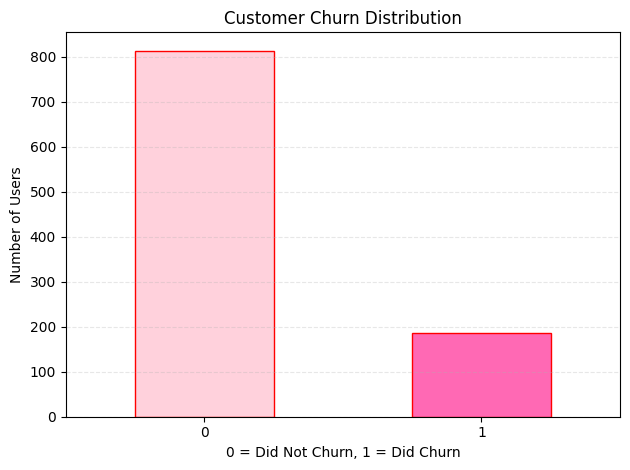

In [104]:
df["churned"].value_counts().plot(
    kind="bar",
    color=["#ffd1dc", "#ff69b4"],
    edgecolor="red",
    linewidth=1
)

plt.title("Customer Churn Distribution")
plt.xlabel("0 = Did Not Churn, 1 = Did Churn")
plt.ylabel("Number of Users")

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

The majority of users are retained, but a significant portion of users churn. This highlights the importance of identifying at-risk users early.

***Churn by Subscription Type***

In this second graph, the overall churn is grouped by the type of subscription the customer holds.

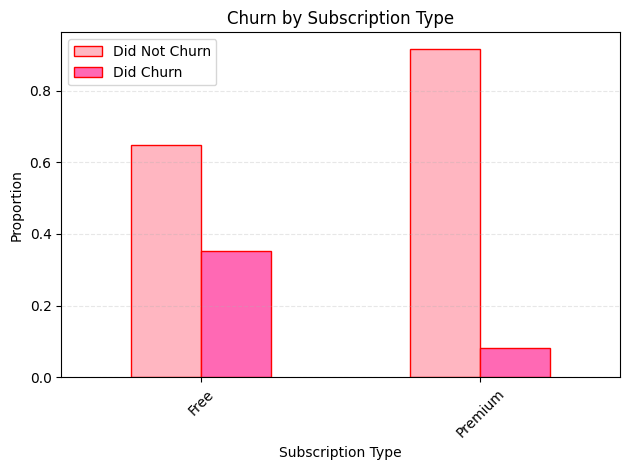

In [120]:
pd.crosstab(df["subscription_type"], df["churned"], normalize="index").plot(
    kind="bar",
    color=["#ffb6c1", "#ff69b4"],
    edgecolor = 'red'
)

plt.title("Churn by Subscription Type")
plt.ylabel("Proportion")
plt.xlabel("Subscription Type")
plt.xticks(rotation=45)
plt.legend(["Did Not Churn", "Did Churn"])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Churn rates are notably higher among free users, while premium users demonstrate significantly stronger retetnion. This indicates that subscription status is a key driver of customer loyalty and engagement.

***Churn by Listening Minutes***

In this third graph, the overall churn is grouped by the average daily listening minutes of each customer.

In [55]:
df.groupby("churned")["avg_daily_minutes"].mean()

,avg_daily_minutes
churned,
0,103.272359
1,71.926882


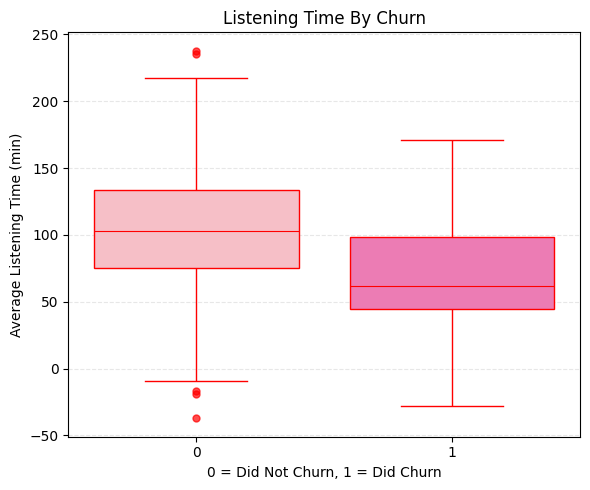

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="churned",
    y="avg_daily_minutes",
    hue='churned',
    palette=["#ffb6c1", "#ff69b4"],
    legend=False,

    boxprops=dict(edgecolor="red"),
    whiskerprops=dict(color="red"),
    capprops=dict(color="red"),
    medianprops=dict(color="red", linewidth=.8),
    flierprops=dict(
        marker='o',
        markerfacecolor='red',
        markeredgecolor="red",
        markersize=5,
        alpha=0.7)

)

plt.title("Listening Time By Churn")
plt.xlabel("0 = Did Not Churn, 1 = Did Churn")
plt.ylabel("Average Listening Time (min)")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

This distribution shows that retained users have consistently higher listening times, while churn users cluster at lower engagement levels. This indicates that declining user activity may serve as an early warning signal for churn.

***Churn by skips per day***

In this fourth graph, the overall churn is grouped by the amount of skips per day by each customer.

In [46]:
df.groupby("churned")["skips_per_day"].mean()

,skips_per_day
churned,
0,4.692875
1,4.360215


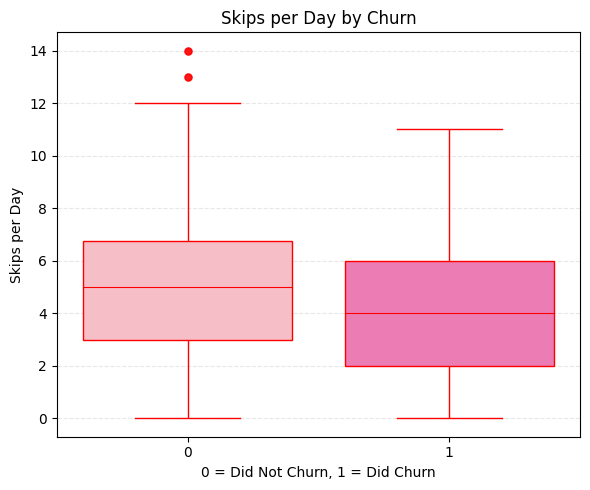

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="churned",
    y="skips_per_day",
    hue='churned',
    palette=["#ffb6c1", "#ff69b4"],
    legend=False,

    boxprops=dict(edgecolor="red"),
    whiskerprops=dict(color="red"),
    capprops=dict(color="red"),
    medianprops=dict(color="red", linewidth=.8),
    flierprops=dict(
        marker='o',
        markerfacecolor='red',
        markeredgecolor="red",
        markersize=5,
        alpha=0.7)
)

plt.title("Skips per Day by Churn")
plt.xlabel("0 = Did Not Churn, 1 = Did Churn")
plt.ylabel("Skips per Day")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

While skipping behavior varies across users, there is no clear separation between churned and retained groups. This indicates that skips per day may not independently drive churn and should be considered alongside other engagement metrics. This highlights the importance of using multiple behaviorial indicators rather than relying on a signal metric to predict churn.

***Churn by days since last login***

In this final graph, the overall churn is grouped by the days since last log in for each customer.

In [47]:
df.groupby("churned")["days_since_last_login"].mean()

,days_since_last_login
churned,
0,8.841523
1,12.360215


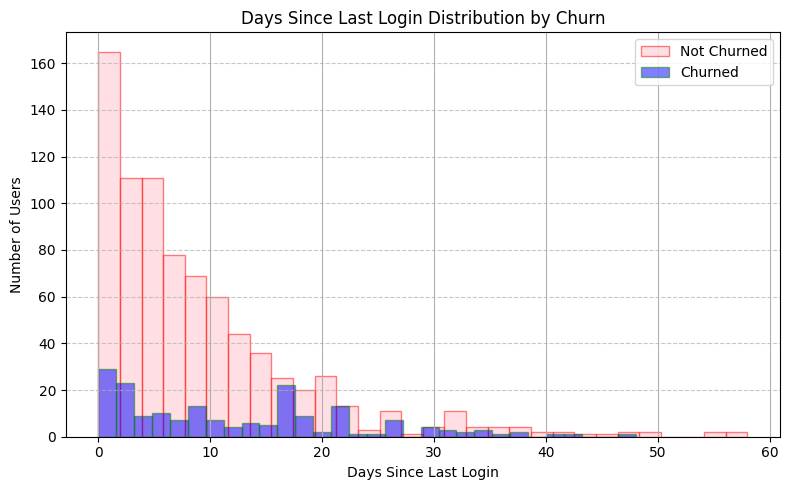

In [81]:
plt.figure(figsize=(8,5))

df[df["churned"] == 0]["days_since_last_login"].hist(
    bins=30,
    alpha=0.5,
    color = "pink",
    edgecolor = 'red',
    label="Not Churned"
)

df[df["churned"] == 1]["days_since_last_login"].hist(
    bins=30,
    alpha=0.5,
    color = 'blue',
    edgecolor = 'green',
    label="Churned"
)

plt.title("Days Since Last Login Churn Distribution")
plt.xlabel("Days Since Last Login")
plt.ylabel("Number of Users")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

The distribution shows that churned users tend to have a higher number of days since their last login, indicating that inactivity is strongly associated with churn. Monitoring user inactivity and targeting users who have not logged in recently may be an effective strategy for reducing churn.

# 5. Predictive Modeling
A decision tree model was used to predict churned based on user behavior variables.

In [60]:
#Prepare Variables
X = df.drop("churned", axis=1)
y = df["churned"]

In [61]:
#Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [66]:
#Train Model

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [67]:
#Predict

y_pred = model.predict(X_test)

In [69]:
#Evaluate

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.775
[[140  24]
 [ 21  15]]
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       164
           1       0.38      0.42      0.40        36

    accuracy                           0.78       200
   macro avg       0.63      0.64      0.63       200
weighted avg       0.78      0.78      0.78       200



The decision tree model achieved an accuracy of approximately 77.5%. While the model performs well in identifying users who are not likely to churn, it shows lower precision and recall for churned users. This suggests that predicting churn is more challenging and may require additional features or more advanced modeling techniques. Despite this limitation, the model still provides valuable insights into the key drivers of churn. Future improvements could include tuning model parameters or using ensemble methods to improve churn prediction accuracy.

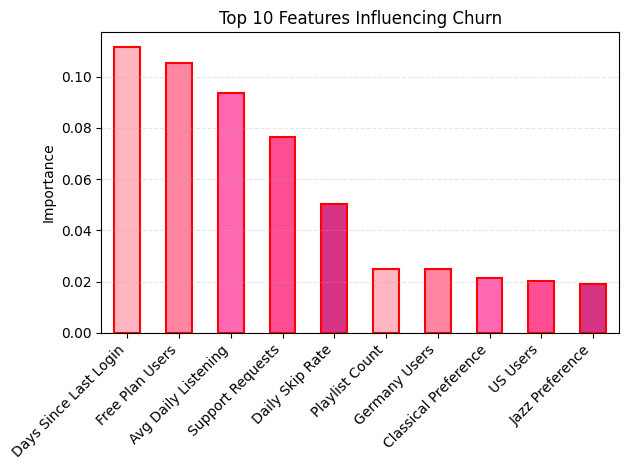

In [119]:
feature_importance = pd.Series(model.feature_importances_, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False).head(10)

rename_dict = {
    "days_since_last_login": "Days Since Last Login",
    "subscription_type_Free": "Free Plan Users",
    "avg_daily_minutes": "Avg Daily Listening",
    "support_tickets": "Support Requests",
    "skips_per_day": "Daily Skip Rate",
    "number_of_playlists": "Playlist Count",
    "country_DE": "Germany Users",
    "country_US": "US Users",
    "top_genre_Classical": "Classical Preference",
    "top_genre_Jazz": "Jazz Preference"
}

feature_importance.index = feature_importance.index.map(lambda x: rename_dict.get(x, x))

colors = ["#ffb6c1", "#ff85a2", "#ff69b4", "#ff4d94", "#d63384",
          "#ffb6c1", "#ff85a2", "#ff69b4", "#ff4d94", "#d63384"]

ax = feature_importance.plot(
    kind="bar",
    color=colors,
    edgecolor="red",
    linewidth=1.5
)

# FIX ALIGNMENT
ax.set_xticks(range(len(feature_importance.index)))
ax.set_xticklabels(feature_importance.index, rotation=45, ha='right')

plt.title("Top 10 Features Influencing Churn")
plt.ylabel("Importance")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Business Recommendations

Based on the analysis of customer behavior and churn patterns, several key strategies can be implemented to improve user retention and reduce churn:

***1. Target Inactive Users with Re-engagement Campaigns***

Users with a higher number of days since last login are significantly more likely to churn. Implementing targeted re-engagement strategies such as push notifications, email reminders, or personalized content recommendations can help bring inactive users back to the platform before they churn.

***2. Increase User Engagement Through Personalization***

Lower listening time is strongly associated with churn. Enhancing personalized recommendations, curated playlists, and user-specific content can increase engagement and encourage users to spend more time on the platform.

***3. Encourage Conversion from Free to Premium Plans***

Free users exhibit significantly higher churn rates compared to premium users. Offering incentives such as free trials, discounts, or exclusive features may help convert free users into paying subscribers, improving retention.

***4. Implement Early Churn Detection Models***

Predictive modeling can help identify users at risk of churning before they leave. By proactively targeting these users with retention strategies, Spotify can reduce churn and improve customer lifetime value.

***5. Monitor Behavioral Signals Holistically***

While some metrics, such as skips per day, do not independently predict churn, combining multiple behavioral indicators provides a more accurate understanding of user risk. A multi-metric approach should be used when designing retention strategies.

These recommendations demonstrate how data-driven insights can be leveraged to improve customer retention and support strategic decision-making.